Average distance between sensors: 10.52 m
Water level variation: min=-2.950 m, max=2.981 m
Max pressure (both sensors): 361616 Pa
Min pressure (both sensors): 226429 Pa
Mean pressure (sensor B): 331499.89 Pa
Standard deviation (sensor B): 13666.96 Pa
Biggest increase in 1 day: 8312.93 Pa/day
Biggest decrease in 1 day: -3688.40 Pa/day
Biggest weekly increase: 15086.98 Pa/week
Biggest weekly decrease: -17988.09 Pa/week


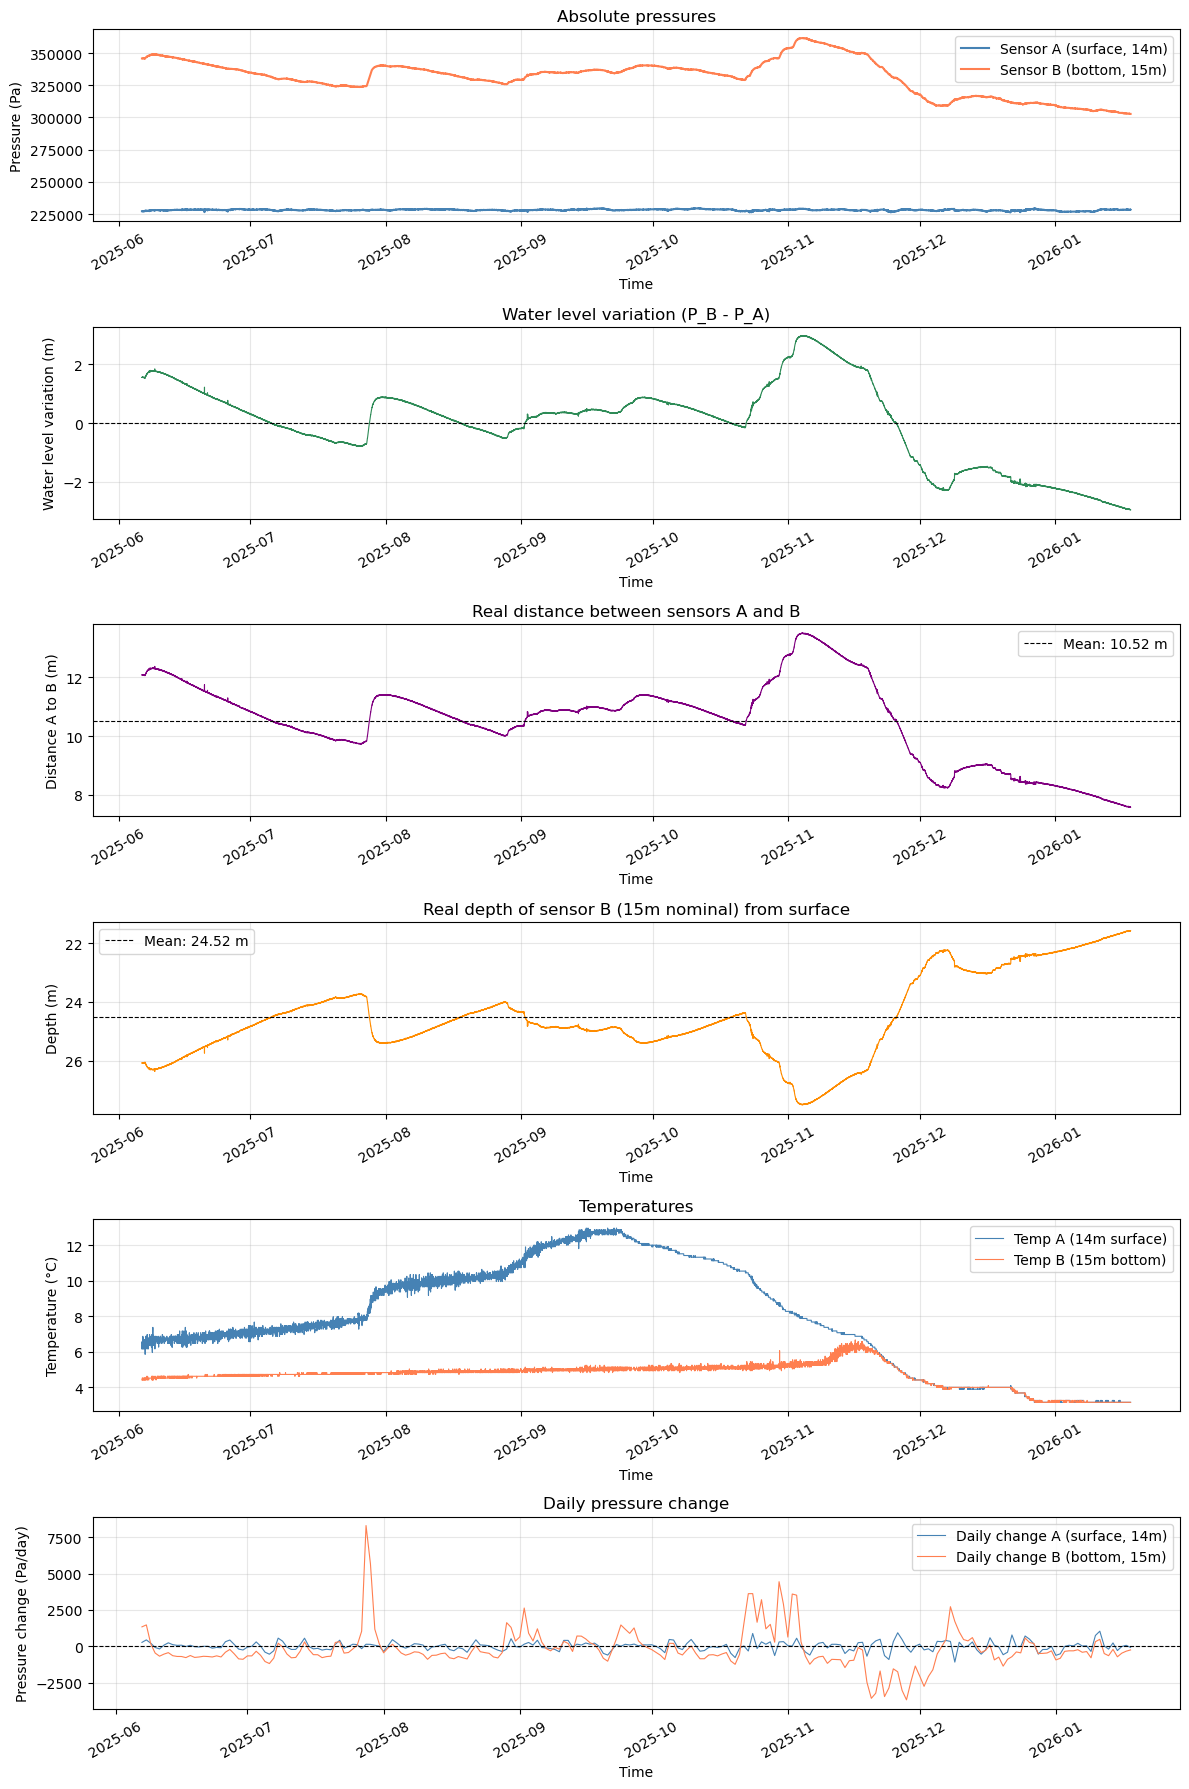

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paths to raw CSV files ---
# Sensor A: attached to surface buoy, always at 14m below the surface
# Sensor B: anchored to the lake bottom, at 15m nominal depth
path_A = '../data/Mooring/HOBO_P/20260603/Level0/20598413_A_14.csv'
path_B = '../data/Mooring/HOBO_P/20260603/Level0/20598412_B_15.csv'

# --- Load pressure and temperature data (skip title row, keep time, pressure and temperature columns) ---
df_A = pd.read_csv(path_A, skiprows=1).iloc[:, [1, 2, 3]].copy()
df_B = pd.read_csv(path_B, skiprows=1).iloc[:, [1, 2, 3]].copy()
df_A.columns = ['time', 'Press_A', 'Temp_A']
df_B.columns = ['time', 'Press_B', 'Temp_B']
df_A['time'] = pd.to_datetime(df_A['time'], format='mixed')
df_B['time'] = pd.to_datetime(df_B['time'], format='mixed')

# --- Merge both sensors on matching timestamps ---
df = pd.merge(df_A, df_B, on='time', how='inner')

# --- Remove individual spike points (anomalous readings identified manually) ---
# Spikes occur on 2025-09-02 and 2025-12-23/24, likely due to sensor handling or maintenance
spike_timestamps = pd.to_datetime([
    '2025-09-02 08:15:00', '2025-09-02 08:30:00', '2025-09-02 09:15:00',
    '2025-09-02 09:30:00', '2025-09-02 09:45:00', '2025-09-02 10:00:00',
    '2025-09-02 10:15:00', '2025-09-02 12:45:00',
    '2025-12-23 23:00:00', '2025-12-24 00:15:00', '2025-12-24 00:30:00'
])
df = df[~df['time'].isin(spike_timestamps)]

# --- Convert pressure difference to meters of water column ---
# 1 Pa = 1 / (rho * g) meters, with rho=1000 kg/m3 and g=9.81 m/s2
Pa_to_m = 1 / (1000 * 9.81)

# Distance between sensors A and B in meters
# P_atm cancels out in the difference since both sensors share the same atmospheric pressure
df['diff_m'] = (df['Press_B'] - df['Press_A']) * Pa_to_m

# Water level variation relative to the mean (positive = water higher than average)
df['delta_wl'] = df['diff_m'] - df['diff_m'].mean()

# Real depth of sensor B (15m nominal) from surface
# Sensor A is always at 14m below surface, so: depth_B = 14m + distance(A to B)
df['depth_B_15m_reel'] = 14.0 + df['diff_m']

# --- Compute daily mean pressure and daily pressure change for both sensors ---
df_daily = df.set_index('time').resample('D').mean()[['Press_A', 'Press_B']]
df_daily['daily_change_A'] = df_daily['Press_A'].diff()
df_daily['daily_change_B'] = df_daily['Press_B'].diff()

# --- Summary statistics ---
print(f"Average distance between sensors: {df['diff_m'].mean():.2f} m")
print(f"Water level variation: min={df['delta_wl'].min():.3f} m, max={df['delta_wl'].max():.3f} m")
print(f"Max pressure (both sensors): {df[['Press_A', 'Press_B']].max().max():.0f} Pa")
print(f"Min pressure (both sensors): {df[['Press_A', 'Press_B']].min().min():.0f} Pa")

# Mean and standard deviation of sensor B (bottom, most representative of water column)
print(f"Mean pressure (sensor B): {df['Press_B'].mean():.2f} Pa")
print(f"Standard deviation (sensor B): {df['Press_B'].std():.2f} Pa")

# Daily pressure change stats (already computed in df_daily)
print(f"Biggest increase in 1 day: {df_daily['daily_change_B'].max():.2f} Pa/day")
print(f"Biggest decrease in 1 day: {df_daily['daily_change_B'].min():.2f} Pa/day")

# Weekly pressure change: resample to weekly means, then diff
df_weekly = df.set_index('time').resample('W').mean()[['Press_B']]
df_weekly['weekly_change_B'] = df_weekly['Press_B'].diff()
print(f"Biggest weekly increase: {df_weekly['weekly_change_B'].max():.2f} Pa/week")
print(f"Biggest weekly decrease: {df_weekly['weekly_change_B'].min():.2f} Pa/week")

# --- Plot all variables (independent x-axes so each subplot shows its own time scale) ---
fig, axes = plt.subplots(6, 1, figsize=(12, 18))

# 1. Absolute pressures in Pa
axes[0].plot(df['time'], df['Press_A'], label='Sensor A (surface, 14m)', color='steelblue')
axes[0].plot(df['time'], df['Press_B'], label='Sensor B (bottom, 15m)', color='coral')
axes[0].set_ylabel('Pressure (Pa)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Absolute pressures')

# 2. Water level variation in meters
axes[1].plot(df['time'], df['delta_wl'], color='seagreen', linewidth=0.8)
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Water level variation (m)')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Water level variation (P_B - P_A)')

# 3. Real distance between sensors A and B
axes[2].plot(df['time'], df['diff_m'], color='purple', linewidth=0.8)
axes[2].axhline(df['diff_m'].mean(), color='k', linestyle='--', linewidth=0.8,
                label=f'Mean: {df["diff_m"].mean():.2f} m')
axes[2].set_ylabel('Distance A to B (m)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Real distance between sensors A and B')

# 4. Real depth of sensor B from surface (y-axis inverted: deeper = down)
axes[3].plot(df['time'], df['depth_B_15m_reel'], color='darkorange', linewidth=0.8)
axes[3].axhline(df['depth_B_15m_reel'].mean(), color='k', linestyle='--', linewidth=0.8,
                label=f'Mean: {df["depth_B_15m_reel"].mean():.2f} m')
axes[3].set_ylabel('Depth (m)')
axes[3].legend()
axes[3].grid(True, alpha=0.3)
axes[3].set_title('Real depth of sensor B (15m nominal) from surface')
axes[3].invert_yaxis()

# 5. Temperature time series for both sensors
axes[4].plot(df['time'], df['Temp_A'], label='Temp A (14m surface)', color='steelblue', linewidth=0.8)
axes[4].plot(df['time'], df['Temp_B'], label='Temp B (15m bottom)', color='coral', linewidth=0.8)
axes[4].set_ylabel('Temperature (°C)')
axes[4].legend()
axes[4].grid(True, alpha=0.3)
axes[4].set_title('Temperatures')

# 6. Daily pressure change for both sensors
axes[5].plot(df_daily.index, df_daily['daily_change_A'], label='Daily change A (surface, 14m)', color='steelblue', linewidth=0.8)
axes[5].plot(df_daily.index, df_daily['daily_change_B'], label='Daily change B (bottom, 15m)', color='coral', linewidth=0.8)
axes[5].axhline(0, color='k', linestyle='--', linewidth=0.8)
axes[5].set_ylabel('Pressure change (Pa/day)')
axes[5].legend()
axes[5].grid(True, alpha=0.3)
axes[5].set_title('Daily pressure change')

# --- Add time label and rotate tick labels on every subplot ---
for ax in axes:
    ax.set_xlabel('Time')
    ax.tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

In [2]:
# --- Corrected depths for chain B sensors at each timestep ---
# Nominal depths of chain B sensors from the surface (in meters)
depth_nominal_B = np.array([3.0, 5.0, 9.0, 15.0, 19.0])

# Build a DataFrame with corrected depths for each sensor
# depth_corrected = depth_nominal + delta_wl
# When water rises (delta_wl > 0), anchored sensors become deeper from the surface
df_depth_B = pd.DataFrame({'time': df['time']})

for d in depth_nominal_B:
    df_depth_B[f'{d}m'] = d + df['delta_wl']

print(df_depth_B.head(10))
print(f"\nShape: {df_depth_B.shape}")


                 time      3.0m      5.0m       9.0m      15.0m      19.0m
0 2025-06-06 08:00:00  4.554954  6.554954  10.554954  16.554954  20.554954
1 2025-06-06 08:15:00  4.553832  6.553832  10.553832  16.553832  20.553832
2 2025-06-06 08:30:00  4.558420  6.558420  10.558420  16.558420  20.558420
3 2025-06-06 08:45:00  4.553323  6.553323  10.553323  16.553323  20.553323
4 2025-06-06 09:00:00  4.554648  6.554648  10.554648  16.554648  20.554648
5 2025-06-06 09:15:00  4.560968  6.560968  10.560968  16.560968  20.560968
6 2025-06-06 09:30:00  4.561478  6.561478  10.561478  16.561478  20.561478
7 2025-06-06 09:45:00  4.555769  6.555769  10.555769  16.555769  20.555769
8 2025-06-06 10:00:00  4.561478  6.561478  10.561478  16.561478  20.561478
9 2025-06-06 10:15:00  4.567390  6.567390  10.567390  16.567390  20.567390

Shape: (21669, 6)


In [3]:
# --- Total lake depth at each timestep ---
# Replace with the actual measured lake depth at mooring B location
depth_total_lake = 19.0  # replace with actual depth in meters

df['depth_lake'] = depth_total_lake + df['delta_wl']

print(df[['time', 'delta_wl', 'depth_lake']].head(10))
print(f"\nLake depth: min={df['depth_lake'].min():.2f}m  mean={df['depth_lake'].mean():.2f}m  max={df['depth_lake'].max():.2f}m")


                 time  delta_wl  depth_lake
0 2025-06-06 08:00:00  1.554954   20.554954
1 2025-06-06 08:15:00  1.553832   20.553832
2 2025-06-06 08:30:00  1.558420   20.558420
3 2025-06-06 08:45:00  1.553323   20.553323
4 2025-06-06 09:00:00  1.554648   20.554648
5 2025-06-06 09:15:00  1.560968   20.560968
6 2025-06-06 09:30:00  1.561478   20.561478
7 2025-06-06 09:45:00  1.555769   20.555769
8 2025-06-06 10:00:00  1.561478   20.561478
9 2025-06-06 10:15:00  1.567390   20.567390

Lake depth: min=16.05m  mean=19.00m  max=21.98m


In [4]:
# --- Real depth of sensor B (pressure sensor at 15m nominal) from surface ---
# Sensor A is fixed at 14m below the surface (attached to buoy)
# The pressure difference gives the real distance between A and B
# => real depth of B = 14m + distance(A to B)
df['depth_B_15m_reel'] = 14.0 + df['diff_m']

print(f"\nReal depth of sensor B (15m nominal):")
print(f"  min  : {df['depth_B_15m_reel'].min():.2f} m")
print(f"  mean : {df['depth_B_15m_reel'].mean():.2f} m")
print(f"  max  : {df['depth_B_15m_reel'].max():.2f} m")



Real depth of sensor B (15m nominal):
  min  : 21.57 m
  mean : 24.52 m
  max  : 27.51 m


In [5]:
# --- Summary statistics of water level variation ---
print(f"Water level variation (delta_wl):")
print(f"  mean : {df['delta_wl'].mean():.3f} m")
print(f"  std  : {df['delta_wl'].std():.3f} m")


Water level variation (delta_wl):
  mean : -0.000 m
  std  : 1.376 m


In [6]:
# --- Largest water level change within a single day ---
# Resample to daily frequency and compute the range (max - min) per day
daily_range = df.set_index('time')['delta_wl'].resample('1D').apply(lambda x: x.max() - x.min())

max_day = daily_range.idxmax()
max_change = daily_range.max()

print(f"Largest change in 1 day: {max_change:.3f} m")
print(f"Date: {max_day.date()}")

print("\nTop 5 days:")
print(daily_range.nlargest(5))


Largest change in 1 day: 0.938 m
Date: 2025-07-28

Top 5 days:
time
2025-07-28    0.938226
2025-11-02    0.549541
2025-10-23    0.536493
2025-10-30    0.515902
2025-12-08    0.459429
Name: delta_wl, dtype: float64


In [7]:
# --- Largest water level change within a single week ---
# Resample to weekly frequency and compute the range (max - min) per week
weekly_range = df.set_index('time')['delta_wl'].resample('1W').apply(lambda x: x.max() - x.min())

max_week = weekly_range.idxmax()
max_change_week = weekly_range.max()

print(f"Largest change in 1 week: {max_change_week:.3f} m")
print(f"Week of: {max_week.date()}")

print("\nTop 5 weeks:")
print(weekly_range.nlargest(5))


Largest change in 1 week: 1.752 m
Week of: 2025-11-30

Top 5 weeks:
time
2025-11-30    1.751784
2025-11-23    1.657798
2025-11-02    1.628644
2025-10-26    1.425076
2025-08-03    1.227727
Name: delta_wl, dtype: float64


In [8]:
# --- Export water level variation to CSV ---
# Split datetime into separate date and time columns for readability
df_wl = pd.DataFrame({
    'date': df['time'].dt.date,
    'time': df['time'].dt.time,
    'delta_wl': df['delta_wl']   # raw water level variation in meters (not filtered)
})

output_path = '../data/Mooring/HOBO_P/20260603/water_level_variation.csv'
df_wl.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(df_wl.head(10))


Saved: ../data/Mooring/HOBO_P/20260603/water_level_variation.csv
         date      time  delta_wl
0  2025-06-06  08:00:00  1.554954
1  2025-06-06  08:15:00  1.553832
2  2025-06-06  08:30:00  1.558420
3  2025-06-06  08:45:00  1.553323
4  2025-06-06  09:00:00  1.554648
5  2025-06-06  09:15:00  1.560968
6  2025-06-06  09:30:00  1.561478
7  2025-06-06  09:45:00  1.555769
8  2025-06-06  10:00:00  1.561478
9  2025-06-06  10:15:00  1.567390
